In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [65]:
ceu_df = pd.read_csv("data/maf_causal/maf_causal_pop_ceu_all.csv")
chb_df = pd.read_csv("data/maf_causal/maf_causal_pop_chb_all.csv")
jpt_df = pd.read_csv("data/maf_causal/maf_causal_pop_jpt_all.csv")
yri_df = pd.read_csv("data/maf_causal/maf_causal_pop_yri_all.csv")

In [69]:
def obtain_summary(df):
    bins = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
    
    labels = [
        "0.01-0.05",
        "0.05-0.1",
        "0.1-0.15",
        "0.15-0.2",
        "0.2-0.3",
        "0.3-0.4",
        "0.4-0.5"
    ]
    
    df["MAF_bin"] = pd.cut(
        df["MAF"],
        bins=bins,
        labels=labels,
        include_lowest=True,
        right=False
    )
    summary = (
        df
        .groupby(["MAF_bin", "causal"], observed=False)["time"]
        .agg(
            median="median",
        )
        .reset_index()
    )

    return summary

In [70]:
summary_data = {}
summary_data["ceu"] = obtain_summary(ceu_df)
summary_data["chb"] = obtain_summary(chb_df)
summary_data["jpt"] = obtain_summary(jpt_df)
summary_data["yri"] = obtain_summary(yri_df)

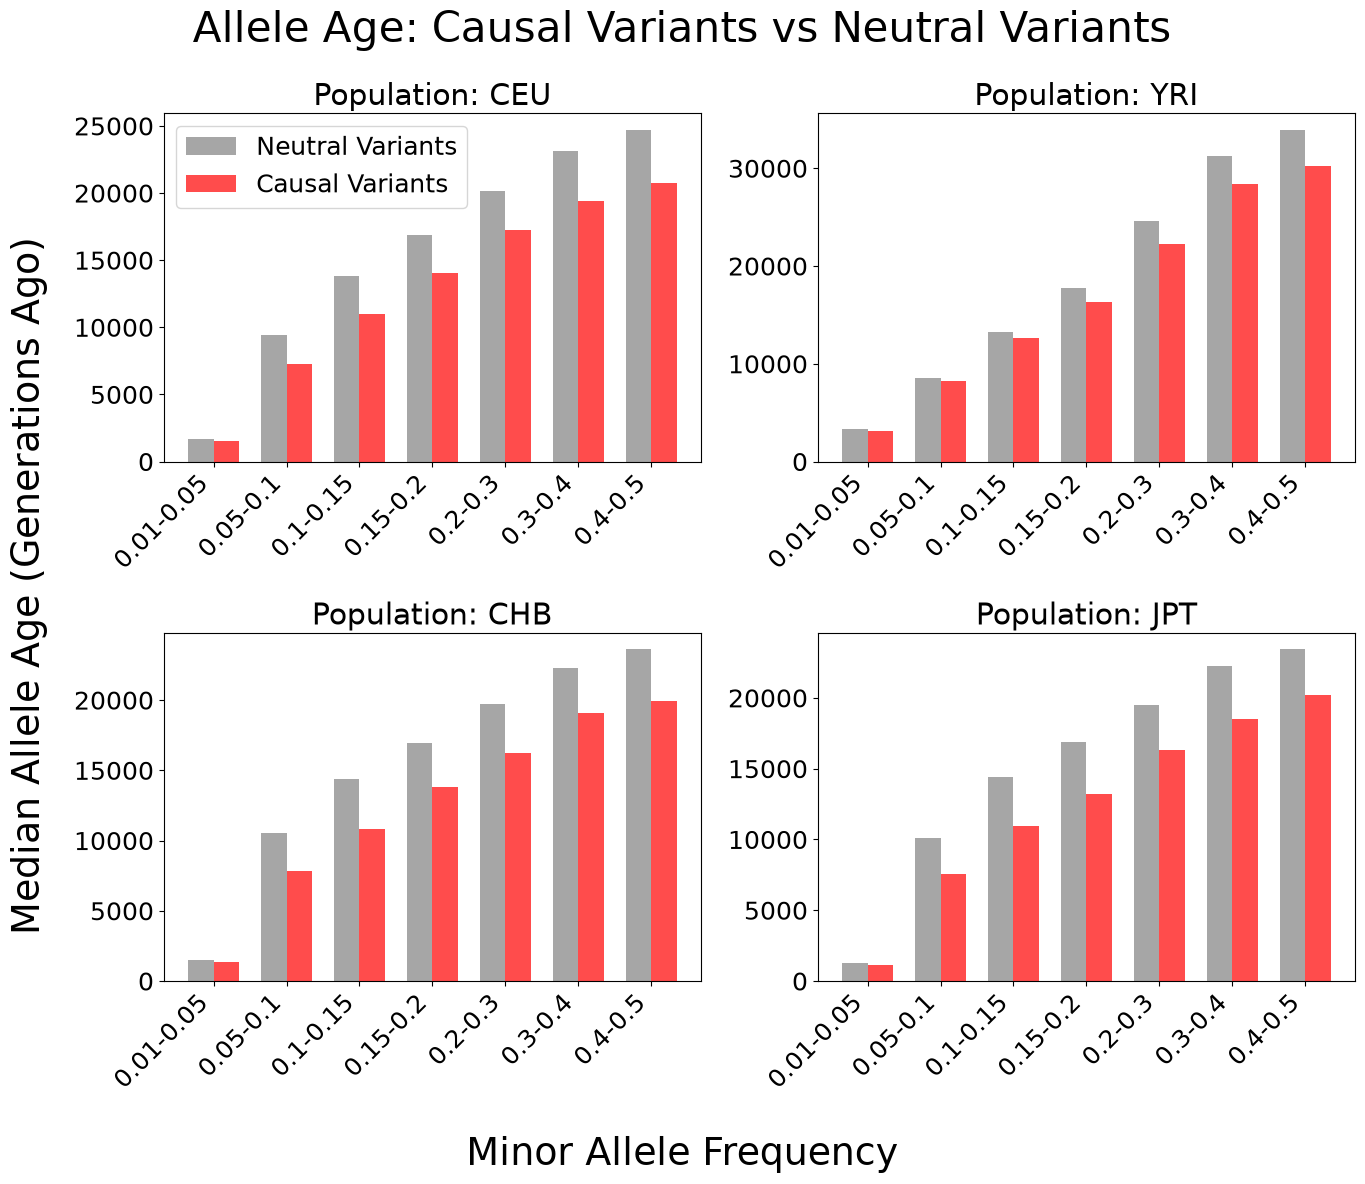

In [71]:
plt.rcParams.update({'font.size': 18})

fig = plt.figure(figsize=(14, 12))
width = 0.35

for i, pop in enumerate(["ceu", "yri", "chb", "jpt"], 1):

    ax = fig.add_subplot(2, 2, i)

    labels = summary_data[pop]["MAF_bin"].unique()
    x = np.arange(len(labels))

    for causal, offset, color, name in [
        (0, -width/2, "gray", "Neutral Variants"),
        (1,  width/2, "red",  "Causal Variants"),
    ]:
        data = summary_data[pop][
            summary_data[pop]["causal"] == causal
        ]

        ax.bar(
            x + offset,
            data["median"],
            width,
            color=color,
            alpha=0.7,
            label=name
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    
    ax.set_title(f"Population: {pop.upper()}")

    if i == 1:
        ax.legend()

fig.suptitle("Allele Age: Causal Variants vs Neutral Variants", size=30)
fig.supxlabel("Minor Allele Frequency", size=27)
fig.supylabel("Median Allele Age (Generations Ago)", size=27)
plt.tight_layout()
plt.savefig("allele-age-causal-neutral.pdf")
plt.show()